<a href="https://colab.research.google.com/github/manugd1105/AI_challenge_UPF/blob/main/Entrenamiento_y_testeo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Elección del modelo e hiperparámetros

Vamos a cargar el conjunto de train, lo dividimos en train y validacion y vamos a probar varios modelos entrenandolos en train y veremos con cual nos quedamos segun su performance en validación

In [ ]:
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Reto de Inteligencia Artificial/df_train_manu.csv")

In [ ]:
df.head()

,audio_file,speaker_id,system_id,label_numerical,label_text,num_temporal_windows,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,...,mfcc_kurt_3,mfcc_kurt_4,mfcc_kurt_5,mfcc_kurt_6,mfcc_kurt_7,mfcc_kurt_8,mfcc_kurt_9,mfcc_kurt_10,mfcc_kurt_11,mfcc_kurt_12
0,/content/LA/ASVspoof2019_LA_train/flac/LA_T_11...,LA_0079,-,0,bonafide,109,-310.40796,43.036842,-18.052126,8.644586,...,1.309874,-0.983724,0.045031,-0.580553,-0.504889,-0.063759,-0.427871,-0.748618,-0.302753,1.553052
1,/content/LA/ASVspoof2019_LA_train/flac/LA_T_12...,LA_0079,-,0,bonafide,138,-330.95712,50.894707,-19.692842,10.769039,...,1.119556,-0.531304,-0.649178,-1.053209,-0.370049,-0.978057,-0.795056,0.493778,1.114291,-0.034808
2,/content/LA/ASVspoof2019_LA_train/flac/LA_T_12...,LA_0079,-,0,bonafide,91,-352.31696,18.402120,0.244028,8.822980,...,0.983940,0.011368,0.288825,0.926077,0.828593,-0.113401,-0.939718,-0.463290,-0.476926,-0.569304
3,/content/LA/ASVspoof2019_LA_train/flac/LA_T_12...,LA_0079,-,0,bonafide,88,-280.84598,48.768970,-7.991325,21.069437,...,-0.633393,-0.965992,-0.608938,0.734988,-0.698169,-0.910887,-0.984191,-0.787603,-0.192135,-1.100056
4,/content/LA/ASVspoof2019_LA_train/flac/LA_T_13...,LA_0079,-,0,bonafide,111,-301.70840,63.264990,-9.561450,-3.289454,...,0.150839,0.560195,-0.117506,-0.600111,-0.150093,-1.282657,-1.159197,-0.441457,-0.084253,0.779144


Tenemos que eliminar el system_id y el label_text porque determinan automaticamente la variable target label_numerical

Ademas, tambien vamos a eliminar audio_file y el speaker_ID ya que no aportan información a la prediccion y, ademas, si añadimos un nuevo registro (de una persona nueva), no vamos a tener valor de LA_0079 (lo que ocurrirá en nuestro conjunto de test, en el cual aparecen personas nuevas).

In [ ]:
df = df.drop(columns=['system_id', 'label_text', 'audio_file', 'speaker_id'])
df.head()

,label_numerical,num_temporal_windows,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,...,mfcc_kurt_3,mfcc_kurt_4,mfcc_kurt_5,mfcc_kurt_6,mfcc_kurt_7,mfcc_kurt_8,mfcc_kurt_9,mfcc_kurt_10,mfcc_kurt_11,mfcc_kurt_12
0,0,109,-310.40796,43.036842,-18.052126,8.644586,-30.472720,-6.541727,-12.117187,-9.478478,...,1.309874,-0.983724,0.045031,-0.580553,-0.504889,-0.063759,-0.427871,-0.748618,-0.302753,1.553052
1,0,138,-330.95712,50.894707,-19.692842,10.769039,-16.535870,-5.034311,-14.371912,-6.454690,...,1.119556,-0.531304,-0.649178,-1.053209,-0.370049,-0.978057,-0.795056,0.493778,1.114291,-0.034808
2,0,91,-352.31696,18.402120,0.244028,8.822980,-8.674293,-6.496036,-6.244439,-3.917905,...,0.983940,0.011368,0.288825,0.926077,0.828593,-0.113401,-0.939718,-0.463290,-0.476926,-0.569304
3,0,88,-280.84598,48.768970,-7.991325,21.069437,-34.162148,-4.567614,-8.792074,-16.917734,...,-0.633393,-0.965992,-0.608938,0.734988,-0.698169,-0.910887,-0.984191,-0.787603,-0.192135,-1.100056
4,0,111,-301.70840,63.264990,-9.561450,-3.289454,-17.743680,-2.535605,-13.747502,-12.589027,...,0.150839,0.560195,-0.117506,-0.600111,-0.150093,-1.282657,-1.159197,-0.441457,-0.084253,0.779144


Ahora vamos a dividir en train y validation, con el fin de utilizar la validation para comparar distintos tipos de modelos.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('label_numerical', axis=1)
y = df['label_numerical']

# Primer split: Dividir el conjunto original en entrenamiento y un conjunto temporal (que luego se dividirá en validación y test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Segundo split: Dividir el conjunto temporal en validación y test
# test_size=0.5 significa que el 50% de 'X_temp' (que es el 20% del total original) irá a test,
# y el otro 50% (otro 20% del total original) irá a validación.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} muestras")
print(f"Tamaño del conjunto de validación: {len(X_val)} muestras")
print(f"Tamaño del conjunto de test: {len(X_test)} muestras")

Tamaño del conjunto de entrenamiento: 15228 muestras
Tamaño del conjunto de validación: 5076 muestras
Tamaño del conjunto de test: 5076 muestras


Antes de entrenar modelos vamos a escalar los datos

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convertir de nuevo a DataFrame si se desea mantener los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

X_train_scaled shape: (20304, 92)
X_val_scaled shape: (5076, 92)


Ahora lo que haremos será probar varios modelos para predecir la y

En todos ellos se aplicaran 5 k-folds para hacer cross-validation y un gridsearch para optimizar los hiperparámetros sobre el conjunto de validación.

Es importante notar que, desde nuestro punto de vista, lo crítico es predecir que un audio es genuino (0) cuando realmente es fake (1), por lo que querremos maximizar el recall para la clase fake (1).

## Regresion logaritmica

Hiperparámetros a optimizar:

- C (Inverso de la fuerza de regularización): Controla la intensidad de la regularización. La regularización es una técnica que se utiliza para evitar el sobreajuste (overfitting) del modelo a los datos de entrenamiento.

- penalty (Tipo de regularización): Define el tipo de penalización que se aplica a los coeficientes del modelo.

  - l1 regularizacion Lasso: Puede llevar a que algunos coeficientes se reduzcan exactamente a cero, lo que efectivamente realiza una selección de características (elimina la influencia de algunas características).
  - l2 regularización Ridge: Tiende a reducir los coeficientes hacia cero, pero rara vez los hace exactamente cero. La regularización L2 es útil para manejar la multicolinealidad entre características.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Define the Logistic Regression model
log_reg = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced') # Added class_weight='balanced' to handle potential class imbalance

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Define the scoring metric: maximize recall for the positive class (1)
# This helps in reducing False Negatives (predicting 0 when actual is 1)
scorer = make_scorer(recall_score, pos_label=1)

# Set up 5-fold stratified cross-validation
# StratifiedKFold ensures that each fold has approximately the same percentage of samples of each target class
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1 # Use all available cores
)

print("Iniciando Grid Search para Regresión Logística...")
# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search completado.")
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Mejores hiperparámetros encontrados: {best_params}")
print(f"Mejor score (recall en entrenamiento): {best_score:.4f}")

# Evaluate the best model on the validation set
best_log_reg_model = grid_search.best_estimator_

print("\nEvaluando el mejor modelo en el conjunto de validación...")
y_val_pred = best_log_reg_model.predict(X_val_scaled)

# Print validation metrics
print("\nClassification Report en el conjunto de validación:")
print(classification_report(y_val, y_val_pred))

print("\nMatriz de Confusión en el conjunto de validación:")
print(confusion_matrix(y_val, y_val_pred))

Iniciando Grid Search para Regresión Logística...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid Search completado.
Mejores hiperparámetros encontrados: {'C': 1, 'penalty': 'l1'}
Mejor score (recall en entrenamiento): 0.9069

Evaluando el mejor modelo en el conjunto de validación...

Classification Report en el conjunto de validación:
              precision    recall  f1-score   support

           0       0.54      0.91      0.68       516
           1       0.99      0.91      0.95      4560

    accuracy                           0.91      5076
   macro avg       0.76      0.91      0.81      5076
weighted avg       0.94      0.91      0.92      5076


Matriz de Confusión en el conjunto de validación:
[[ 470   46]
 [ 402 4158]]


## Decission Tree Classifier

Hiperparámetros a optimizar:

- max_depth: Número máximo de ramificaciones

- min_samples_leaf: Numero mínimo de samples necesarios para generar una ramificación

- criterion: Función para medir la calidad de cada ramificación

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Define the Decision Tree Classifier model
dt_classifier = DecisionTreeClassifier(random_state=42, class_weight='balanced') # Added class_weight='balanced'

# Define the parameter grid to search for Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None], # Max depth of the tree, None means unlimited
    'min_samples_leaf': [1, 5, 10, 20], # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Define the scoring metric: maximize recall for the positive class (1)
scorer = make_scorer(recall_score, pos_label=1)

# Set up 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid_dt,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1 # Use all available cores
)

print("Iniciando Grid Search para Decision Tree Classifier...")
# Fit GridSearchCV on the scaled training data
grid_search_dt.fit(X_train_scaled, y_train)

print("\nGrid Search completado para Decision Tree Classifier.")
# Get the best parameters and best score
best_params_dt = grid_search_dt.best_params_
best_score_dt = grid_search_dt.best_score_

print(f"Mejores hiperparámetros encontrados para Decision Tree: {best_params_dt}")
print(f"Mejor score (recall en entrenamiento) para Decision Tree: {best_score_dt:.4f}")

# Evaluate the best model on the validation set
best_dt_model = grid_search_dt.best_estimator_

print("\nEvaluando el mejor modelo de Decision Tree en el conjunto de validación...")
y_val_pred_dt = best_dt_model.predict(X_val_scaled)

# Print validation metrics
print("\nClassification Report en el conjunto de validación para Decision Tree:")
print(classification_report(y_val, y_val_pred_dt))

print("\nMatriz de Confusión en el conjunto de validación para Decision Tree:")
print(confusion_matrix(y_val, y_val_pred_dt))

Iniciando Grid Search para Decision Tree Classifier...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Grid Search completado para Decision Tree Classifier.
Mejores hiperparámetros encontrados para Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}
Mejor score (recall en entrenamiento) para Decision Tree: 0.9667

Evaluando el mejor modelo de Decision Tree en el conjunto de validación...

Classification Report en el conjunto de validación para Decision Tree:
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       516
           1       0.96      0.96      0.96      4560

    accuracy                           0.93      5076
   macro avg       0.82      0.82      0.82      5076
weighted avg       0.93      0.93      0.93      5076


Matriz de Confusión en el conjunto de validación para Decision Tree:
[[ 351  165]
 [ 168 4392]]


## Random Forest Classifier

Hiperparámetros a optimizar:

- n_estimators: Número de árboles de decisión en el Random Forest.

- max_depth: Máximo número de ramificaciones en cada árbol de decisión.

- min_samples_leaf: Mínimo número de samples necesarios para generar una ramificación.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Define the Random Forest Classifier model
rf_classifier = RandomForestClassifier(random_state=42, class_weight='balanced') # Added class_weight='balanced'

# Define the parameter grid to search for Random Forest Classifier
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [5, 10, None],      # Maximum depth of the tree
    'min_samples_leaf': [1, 5, 10]   # Minimum number of samples required to be at a leaf node
}

# Define the scoring metric: maximize recall for the positive class (1)
scorer = make_scorer(recall_score, pos_label=1)

# Set up 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=skf,
    verbose=1, # Set verbose to 1 for basic progress output
    n_jobs=-1 # Use all available cores
)

print("Iniciando Grid Search para Random Forest Classifier...")
# Fit GridSearchCV on the scaled training data
grid_search_rf.fit(X_train_scaled, y_train)

print("\nGrid Search completado para Random Forest Classifier.")
# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Mejores hiperparámetros encontrados para Random Forest: {best_params_rf}")
print(f"Mejor score (recall en entrenamiento) para Random Forest: {best_score_rf:.4f}")

# Evaluate the best model on the validation set
best_rf_model = grid_search_rf.best_estimator_

print("\nEvaluando el mejor modelo de Random Forest en el conjunto de validación...")
y_val_pred_rf = best_rf_model.predict(X_val_scaled)

# Print validation metrics
print("\nClassification Report en el conjunto de validación para Random Forest:")
print(classification_report(y_val, y_val_pred_rf))

print("\nMatriz de Confusión en el conjunto de validación para Random Forest:")
print(confusion_matrix(y_val, y_val_pred_rf))

Iniciando Grid Search para Random Forest Classifier...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Grid Search completado para Random Forest Classifier.
Mejores hiperparámetros encontrados para Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor score (recall en entrenamiento) para Random Forest: 0.9974

Evaluando el mejor modelo de Random Forest en el conjunto de validación...

Classification Report en el conjunto de validación para Random Forest:
              precision    recall  f1-score   support

           0       0.97      0.60      0.74       516
           1       0.96      1.00      0.98      4560

    accuracy                           0.96      5076
   macro avg       0.96      0.80      0.86      5076
weighted avg       0.96      0.96      0.95      5076


Matriz de Confusión en el conjunto de validación para Random Forest:
[[ 311  205]
 [  10 4550]]


## Support Vector Machine (SVM)

Hiperparámetros a probar:

- C (Parámetro de regularización): Idem a regresion logistica

- kernel: Función matemática que toma tus datos y los proyecta a una dimensión geométrica superior donde sí se puedan separar fácilmente

- gamma: Solo entra en juego cuando se usan kernels no lineales (como el rbf). Define qué tan lejos llega la influencia de un solo punto de dato en el entrenamiento.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Define the Support Vector Classifier model
svm_classifier = SVC(random_state=42, class_weight='balanced') # Added class_weight='balanced'

# Define the parameter grid to search for SVM Classifier
# Starting with a smaller grid due to potential computational cost of SVM
param_grid_svm = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'kernel': ['linear', 'rbf'], # Specifies the kernel type to be used
    'gamma': ['scale', 'auto'] # Kernel coefficient for 'rbf'
}

# Define the scoring metric: maximize recall for the positive class (1)
scorer = make_scorer(recall_score, pos_label=1)

# Set up 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm_classifier,
    param_grid=param_grid_svm,
    scoring=scorer,
    cv=skf,
    verbose=1, # Set verbose to 1 for basic progress output
    n_jobs=-1 # Use all available cores
)

print("Iniciando Grid Search para SVM Classifier...")
# Fit GridSearchCV on the scaled training data
grid_search_svm.fit(X_train_scaled, y_train)

print("\nGrid Search completado para SVM Classifier.")
# Get the best parameters and best score
best_params_svm = grid_search_svm.best_params_
best_score_svm = grid_search_svm.best_score_

print(f"Mejores hiperparámetros encontrados para SVM: {best_params_svm}")
print(f"Mejor score (recall en entrenamiento): {best_score_svm:.4f}")

# Evaluate the best model on the validation set
best_svm_model = grid_search_svm.best_estimator_

print("\nEvaluando el mejor modelo de SVM en el conjunto de validación...")
y_val_pred_svm = best_svm_model.predict(X_val_scaled)

# Print validation metrics
print("\nClassification Report en el conjunto de validación para SVM:")
print(classification_report(y_val, y_val_pred_svm))

print("\nMatriz de Confusión en el conjunto de validación para SVM:")
print(confusion_matrix(y_val, y_val_pred_svm))

Iniciando Grid Search para SVM Classifier...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid Search completado para SVM Classifier.
Mejores hiperparámetros encontrados para SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor score (recall en entrenamiento): 0.9958

Evaluando el mejor modelo de SVM en el conjunto de validación...

Classification Report en el conjunto de validación para SVM:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       516
           1       0.99      0.99      0.99      4560

    accuracy                           0.99      5076
   macro avg       0.97      0.97      0.97      5076
weighted avg       0.99      0.99      0.99      5076


Matriz de Confusión en el conjunto de validación para SVM:
[[ 486   30]
 [  28 4532]]


## k-NN

Hiperparámetros a optimizar:

- n_neighbors

- weights

- metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Define the k-NN Classifier model
# k-NN does not have a direct 'class_weight' parameter like other models.
# Class imbalance can sometimes be handled by 'weights="distance"'
# or by over/undersampling techniques outside of GridSearchCV.
# For now, we'll keep the default 'uniform' weights but can explore 'distance' later if needed.
knn_classifier = KNeighborsClassifier()

# Define the parameter grid to search for k-NN Classifier
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15], # Number of neighbors to consider
    'weights': ['uniform', 'distance'],      # Weight function used in prediction
    'metric': ['euclidean', 'manhattan']     # Distance metric to use
}

# Define the scoring metric: maximize recall for the positive class (1)
scorer = make_scorer(recall_score, pos_label=1)

# Set up 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=knn_classifier,
    param_grid=param_grid_knn,
    scoring=scorer,
    cv=skf,
    verbose=1, # Set verbose to 1 for basic progress output
    n_jobs=-1  # Use all available cores
)

print("Iniciando Grid Search para k-NN Classifier...")

# Fit GridSearchCV on the scaled training data
grid_search_knn.fit(X_train_scaled, y_train)

print("\nGrid Search completado para k-NN Classifier.")
# Get the best parameters and best score
best_params_knn = grid_search_knn.best_params_
best_score_knn = grid_search_knn.best_score_

print(f"Mejores hiperparámetros encontrados para k-NN: {best_params_knn}")
print(f"Mejor score (recall en entrenamiento) para k-NN: {best_score_knn:.4f}")

# Evaluate the best model on the validation set
best_knn_model = grid_search_knn.best_estimator_

print("\nEvaluando el mejor modelo de k-NN en el conjunto de validación...")
y_val_pred_knn = best_knn_model.predict(X_val_scaled)

# Print validation metrics
print("\nClassification Report en el conjunto de validación para k-NN:")
print(classification_report(y_val, y_val_pred_knn))

print("\nMatriz de Confusión en el conjunto de validación para k-NN:")
print(confusion_matrix(y_val, y_val_pred_knn))

Iniciando Grid Search para k-NN Classifier...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Grid Search completado para k-NN Classifier.
Mejores hiperparámetros encontrados para k-NN: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'}
Mejor score (recall en entrenamiento) para k-NN: 0.9941

Evaluando el mejor modelo de k-NN en el conjunto de validación...

Classification Report en el conjunto de validación para k-NN:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       516
           1       0.99      0.99      0.99      4560

    accuracy                           0.98      5076
   macro avg       0.97      0.95      0.96      5076
weighted avg       0.98      0.98      0.98      5076


Matriz de Confusión en el conjunto de validación para k-NN:
[[ 463   53]
 [  26 4534]]


## XG-Boost

Hiperparámetros a optimizar:

- n_estimators:

- learning_rate:

- max_depth:

- subsample:

- colsample_bytree:

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Define the XGBoost Classifier model
# Use scale_pos_weight to handle class imbalance, calculating it based on y_train
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning for older XGBoost versions
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

# Define the parameter grid to search for XGBoost Classifier
param_grid_xgb = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7],           # Maximum depth of a tree
    'subsample': [0.7, 0.9],          # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.9]    # Subsample ratio of columns when constructing each tree
}

# Define the scoring metric: maximize recall for the positive class (1)
scorer = make_scorer(recall_score, pos_label=1)

# Set up 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_classifier,
    param_grid=param_grid_xgb,
    scoring=scorer,
    cv=skf,
    verbose=1, # Set verbose to 1 for basic progress output
    n_jobs=-1 # Use all available cores
)

print("Iniciando Grid Search para XGBoost Classifier...")

# Fit GridSearchCV on the scaled training data
grid_search_xgb.fit(X_train_scaled, y_train)

print("\nGrid Search completado para XGBoost Classifier.")
# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"Mejores hiperparámetros encontrados para XGBoost: {best_params_xgb}")
print(f"Mejor score (recall en entrenamiento): {best_score_xgb:.4f}")

# Evaluate the best model on the validation set
best_xgb_model = grid_search_xgb.best_estimator_

print("\nEvaluando el mejor modelo de XGBoost en el conjunto de validación...")
y_val_pred_xgb = best_xgb_model.predict(X_val_scaled)

# Print validation metrics
print("\nClassification Report en el conjunto de validación para XGBoost:")
print(classification_report(y_val, y_val_pred_xgb))

print("\nMatriz de Confusión en el conjunto de validación para XGBoost:")
print(confusion_matrix(y_val, y_val_pred_xgb))

Iniciando Grid Search para XGBoost Classifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Grid Search completado para XGBoost Classifier.
Mejores hiperparámetros encontrados para XGBoost: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.9}
Mejor score (recall en entrenamiento): 0.9928

Evaluando el mejor modelo de XGBoost en el conjunto de validación...

Classification Report en el conjunto de validación para XGBoost:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       516
           1       0.99      0.99      0.99      4560

    accuracy                           0.99      5076
   macro avg       0.96      0.96      0.96      5076
weighted avg       0.99      0.99      0.99      5076


Matriz de Confusión en el conjunto de validación para XGBoost:
[[ 479   37]
 [  34 4526]]


## Redes Neuronales

Hiperparámetros a probar:

- hidden_layer_sizes

- activation

- alpha

- solver

- max_iter

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Define the MLPClassifier model
# Set random_state for reproducibility
# Set early_stopping=True to stop training when validation score does not improve
mlp_classifier = MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=10)

# Define the parameter grid to search for MLPClassifier
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)], # One hidden layer with 50 or 100 neurons, or two layers of 50 neurons
    'activation': ['relu', 'tanh'],               # Activation function for the hidden layer
    'alpha': [0.0001, 0.001, 0.01],               # L2 penalty (regularization term) parameter
    'solver': ['adam'],                           # The solver for weight optimization (adam is often a good default)
    'max_iter': [200]                             # Maximum number of iterations (epochs)
}

# Define the scoring metric: maximize recall for the positive class (1)
scorer = make_scorer(recall_score, pos_label=1)

# Set up 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search_mlp = GridSearchCV(
    estimator=mlp_classifier,
    param_grid=param_grid_mlp,
    scoring=scorer,
    cv=skf,
    verbose=1, # Set verbose to 1 for basic progress output, as requested not to use a progress bar
    n_jobs=-1  # Use all available cores
)

print("Iniciando Grid Search para MLP Classifier (Red Neuronal)...")

# Fit GridSearchCV on the scaled training data
grid_search_mlp.fit(X_train_scaled, y_train)

print("\nGrid Search completado para MLP Classifier (Red Neuronal).")
# Get the best parameters and best score
best_params_mlp = grid_search_mlp.best_params_
best_score_mlp = grid_search_mlp.best_score_

print(f"Mejores hiperparámetros encontrados para MLP Classifier: {best_params_mlp}")
print(f"Mejor score (recall en entrenamiento) para MLP Classifier: {best_score_mlp:.4f}")

# Evaluate the best model on the validation set
best_mlp_model = grid_search_mlp.best_estimator_

print("\nEvaluando el mejor modelo de MLP Classifier en el conjunto de validación...")
y_val_pred_mlp = best_mlp_model.predict(X_val_scaled)

# Print validation metrics
print("\nClassification Report en el conjunto de validación para MLP Classifier:")
print(classification_report(y_val, y_val_pred_mlp))

print("\nMatriz de Confusión en el conjunto de validación para MLP Classifier:")
print(confusion_matrix(y_val, y_val_pred_mlp))

Iniciando Grid Search para MLP Classifier (Red Neuronal)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Grid Search completado para MLP Classifier (Red Neuronal).
Mejores hiperparámetros encontrados para MLP Classifier: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'max_iter': 200, 'solver': 'adam'}
Mejor score (recall en entrenamiento) para MLP Classifier: 0.9952

Evaluando el mejor modelo de MLP Classifier en el conjunto de validación...

Classification Report en el conjunto de validación para MLP Classifier:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       516
           1       0.99      0.99      0.99      4560

    accuracy                           0.99      5076
   macro avg       0.97      0.96      0.97      5076
weighted avg       0.99      0.99      0.99      5076


Matriz de Confusión en el conjunto de validación para MLP Classifier:
[[ 477   39]
 [  24 4536]]


Bajo el criterio que buscábamos, el modelo que más ha reducido los falsos positivos (es decir, ha maximizado el recall) ha sido el Random Forest Classifier con los hiperparámetros optimizados.

En la siguiente sección, entrenaremos este modelo que hemos encontrado como el óptimo para la combinación de train + validation y, tras ello, evaluaremos una última vez sobre el conjunto de test (el cual cargaremos)

# Entrenamiento del modelo final y evaluación en test

Construimos el conjunto de test final y lo limpiamos igual que hicimos antes con train y eval.

Ahora, construimos el conjunto de train final (df_train + df_val anterior).

Como vamos a utilizar un random forest classifier, no hace falta escalar ya para este algoritmo no influye el escalado.

Lo que vamos a hacer ahora es encontrar el número de datos necesarios para entrenar el modelo final. Para ello, haremos una curva de aprendizaje del modelo. Recordamos que los parámetros óptimos encontrados son:

- 'max_depth': None
- 'min_samples_leaf': 1
- 'n_estimators': 200

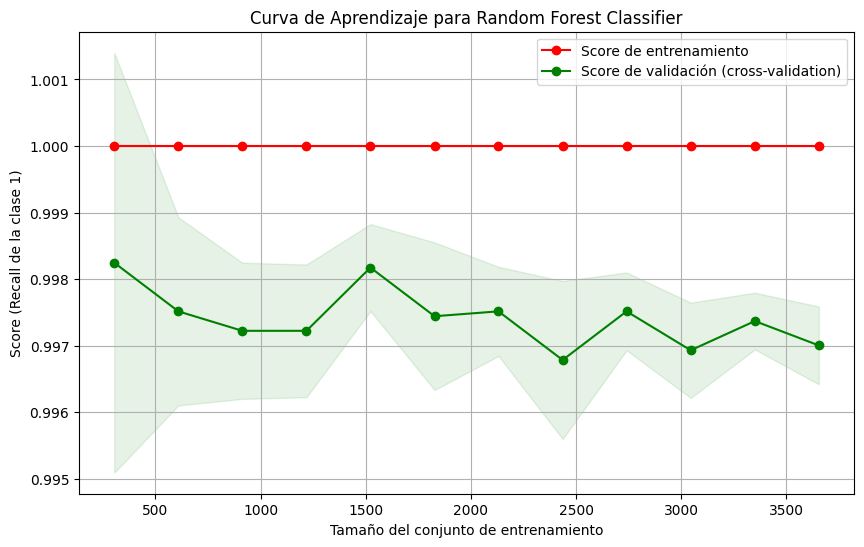

Último score promedio de entrenamiento: 1.0000
Último score promedio de validación: 0.9970


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, make_scorer
import pandas as pd

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

scorer = make_scorer(recall_score, pos_label=1)

train_sizes, train_scores, test_scores = learning_curve(
    rf_classifier,
    X_train,
    y_train,
    cv=5, # Using 5-fold cross-validation
    scoring=scorer,
    n_jobs=-1, # Use all available cores
    train_sizes=np.linspace(0.025, 0.3, 12), # Use 12 different sizes from 2.5% to 30% of the training data
    random_state=42
)

# Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.title("Curva de Aprendizaje para Random Forest Classifier")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Score (Recall de la clase 1)")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1,
                 color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Score de entrenamiento")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Score de validación (cross-validation)")

plt.legend(loc="best")
plt.show()

print(f"Último score promedio de entrenamiento: {train_scores_mean[-1]:.4f}")
print(f"Último score promedio de validación: {test_scores_mean[-1]:.4f}")

Podemos observar en la curva que a partir de 3000 datos en el entrenamiento que la curva ya no mejora, por lo que utilizaremos dicha cantidad de datos en el conjunto de train.

Se observa un ligero overfitting, ya que todos los datos de entrenamiento los memoriza perfectamente. No obstante, esto es muy asumible, ya que en los datos nuevos solo baja menos de un 0.01 en recall.



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Best hyperparameters for Random Forest found from GridSearchCV were:
# {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

# Initialize the final Random Forest Classifier model with optimal hyperparameters
modelo_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42, # Ensure reproducibility
    class_weight='balanced', # To handle class imbalance, as used in previous steps
    n_jobs=-1 # Use all available cores for training
)

# Select the first 4500 samples from the combined training data (X_train_final and y_train_final)
# as indicated by the learning curve analysis.
X_train_3000 = X_train.head(3000)
y_train_3000 = y_train.head(3000)

# Train the final model
modelo_final.fit(X_train_3000, y_train_3000)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

Con este modelo, vamos a plotear unas cuantas métricas y gráficas para visualizar mejor la performance de nuestro modelo y las features más importantes.

## Matriz de confusión

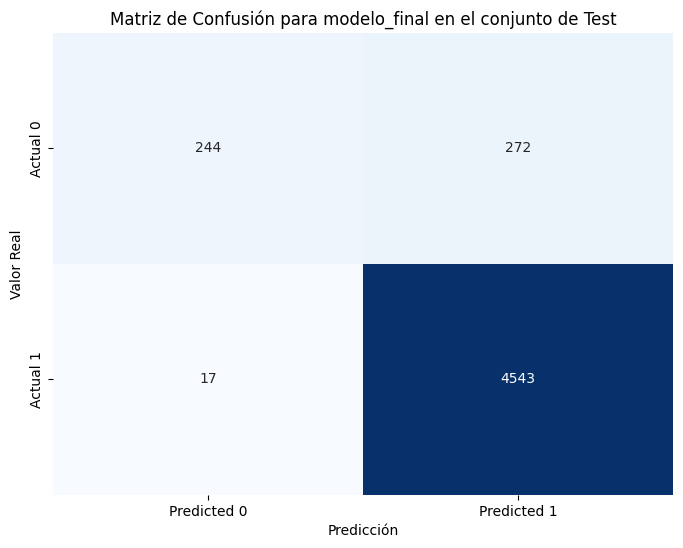

Matriz de Confusión:
[[ 244  272]
 [  17 4543]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# Make predictions on the processed test set using the final model
y_pred = modelo_final.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión para modelo_final en el conjunto de Test')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

print("Matriz de Confusión:")
print(cm)

## Métricas principales

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Assuming y_pred and y_test are already defined from previous cells
# y_pred = modelo_final.predict(X_test)

print("Classification Report del modelo_final en el conjunto de Test:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo_final en el conjunto de Test: {accuracy:.4f}")

Classification Report del modelo_final en el conjunto de Test:
              precision    recall  f1-score   support

           0       0.93      0.47      0.63       516
           1       0.94      1.00      0.97      4560

    accuracy                           0.94      5076
   macro avg       0.94      0.73      0.80      5076
weighted avg       0.94      0.94      0.93      5076

Accuracy del modelo_final en el conjunto de Test: 0.9431


# Análisis del desbalanceo

Como vimos, es obvio que hay un claro desbalanceo hacia la clase 1 (fake). Es por ello que nos queremos analizar si, al balancear los datos, nuestro modelo cambia mucho.

Basándonos en la curva de aprendizaje realizada anteriomente, se observa que se obtiene un recall muy bueno incluso con conjuntos de entrenamiento pequeños, por lo que nos inclinaremos por emplear undersampling.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("Distribución original de las clases en y_train:", Counter(y_train))

# Instantiate RandomUnderSampler
# random_state for reproducibility
# sampling_strategy='auto' balances the majority class to the minority class
undersampler = RandomUnderSampler(random_state=42, sampling_strategy='auto')

# Apply undersampling to X_train and y_train
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

print("Distribución de las clases en y_train después de undersampling:", Counter(y_train_resampled))
print(f"Dimensiones de X_train después de undersampling: {X_train_resampled.shape}")
print(f"Dimensiones de y_train después de undersampling: {y_train_resampled.shape}")

Distribución original de las clases en y_train: Counter({1: 13680, 0: 1548})
Distribución de las clases en y_train después de undersampling: Counter({0: 1548, 1: 1548})
Dimensiones de X_train después de undersampling: (3096, 92)
Dimensiones de y_train después de undersampling: (3096,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Best hyperparameters for Random Forest found from GridSearchCV were:
# {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

# Initialize the final Random Forest Classifier model with optimal hyperparameters
# and train it on the resampled data
modelo_final_balanceado = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42, # Ensure reproducibility
    class_weight='balanced', # Important to use with imbalanced data, even after resampling
    n_jobs=-1 # Use all available cores for training
)

# Train the final balanced model with the resampled training data
modelo_final_balanceado.fit(X_train_resampled, y_train_resampled)

print("Modelo 'modelo_final_balanceado' entrenado con éxito usando datos balanceados.")

Modelo 'modelo_final_balanceado' entrenado con éxito usando datos balanceados.


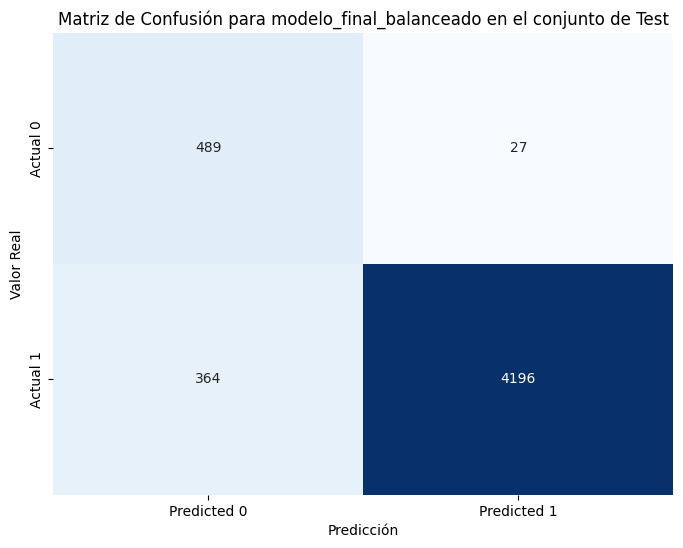

Matriz de Confusión para modelo_final_balanceado:
[[ 489   27]
 [ 364 4196]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set using the balanced final model
y_pred_balanced = modelo_final_balanceado.predict(X_test)

# Generate the confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión para modelo_final_balanceado en el conjunto de Test')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

print("Matriz de Confusión para modelo_final_balanceado:")
print(cm_balanced)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Assuming y_pred_balanced and y_test are already defined from previous cells
print("Classification Report del modelo_final_balanceado en el conjunto de Test:")
print(classification_report(y_test, y_pred_balanced))

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(f"Accuracy del modelo_final_balanceado en el conjunto de Test: {accuracy_balanced:.4f}")

Classification Report del modelo_final_balanceado en el conjunto de Test:
              precision    recall  f1-score   support

           0       0.57      0.95      0.71       516
           1       0.99      0.92      0.96      4560

    accuracy                           0.92      5076
   macro avg       0.78      0.93      0.83      5076
weighted avg       0.95      0.92      0.93      5076

Accuracy del modelo_final_balanceado en el conjunto de Test: 0.9230


# Análisis de las distintas generaciones de audio

Para ver cómo funciona la genralización del modelo entrenado, vamos a probar a intentar entrenar un modelo con audios generados solo un sistema de generación (y todos los genuinos, obviamente)

In [80]:
import pandas as pd

df_temp_analysis = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Reto de Inteligencia Artificial/df_train_manu.csv")

df_1_train = df_temp_analysis[(df_temp_analysis['system_id'] == "-") | (df_temp_analysis['system_id'] == "A01")]
df_1_train = df_1_train.drop(columns=['system_id', 'label_text', 'audio_file', 'speaker_id'])

df_1_test = df_temp_analysis[(df_temp_analysis['system_id'] != "-") & (df_temp_analysis['system_id'] != "A01")]
df_1_test = df_1_test.drop(columns=['system_id', 'label_text', 'audio_file', 'speaker_id'])

In [81]:
df_temp_analysis.system_id.value_counts()

,count
system_id,
A01,3800
A02,3800
A03,3800
A05,3800
A04,3800
A06,3800
-,2580


In [82]:
X_1_train = df_1_train.drop('label_numerical', axis=1)
y_1_train = df_1_train['label_numerical']

X_1_test = df_1_test.drop('label_numerical', axis=1)
y_1_test = df_1_test['label_numerical']

In [83]:
from sklearn.ensemble import RandomForestClassifier

# Optimal hyperparameters for Random Forest found previously
optimal_params_rf = {
    'n_estimators': 200,
    'max_depth': None,
    'min_samples_leaf': 1
}

# Initialize the Random Forest Classifier with optimal hyperparameters
rf_classifier_1_optimal = RandomForestClassifier(
    **optimal_params_rf,
    random_state=42, # For reproducibility
    class_weight='balanced', # To handle class imbalance, as used previously
    n_jobs=-1 # Use all available cores for training
)

# Train the model on X_1_train and y_1_train
rf_classifier_1_optimal.fit(X_1_train, y_1_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

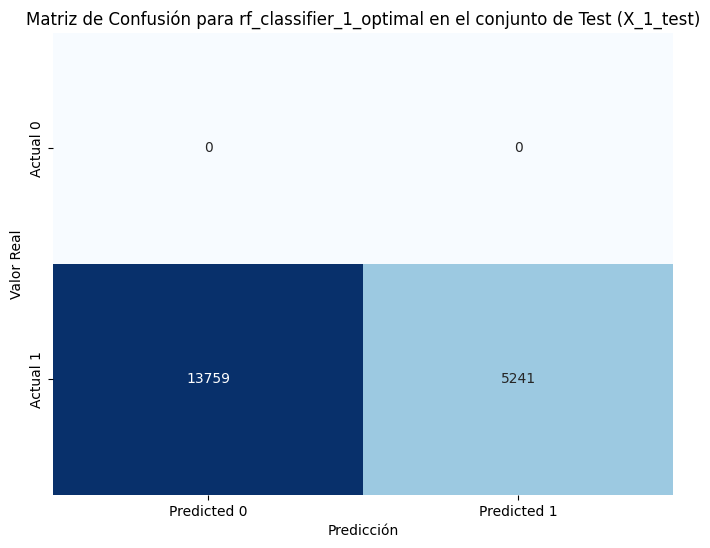

Matriz de Confusión para rf_classifier_1_optimal en el conjunto de Test:
[[    0     0]
 [13759  5241]]


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Make predictions on the X_1_test set using the trained model
y_1_pred = rf_classifier_1_optimal.predict(X_1_test)

# Generate the confusion matrix
cm_1 = confusion_matrix(y_1_test, y_1_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión para rf_classifier_1_optimal en el conjunto de Test (X_1_test)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

print("Matriz de Confusión para rf_classifier_1_optimal en el conjunto de Test:")
print(cm_1)